Particles of interest: 101 (ejected), 104 (collided w/ Sun), 106 (collided w/ Sun). 

In [1]:
# Setup

import rebound
import numpy as np
import matplotlib.pyplot as plt
from rebound import hash as h

interest = [101, 104, 106]

MONITOR SIMULATION AS IT RUNS

In [2]:
# Import simulation archive

sa = rebound.Simulationarchive("outputs/orbital_integration/archive.bin")

print("Number of snapshots: {}".format(len(sa)))
print("Time of first and last snapshot: {:.1f}, {:.1f}".format(sa.tmin, sa.tmax))

N_pl = 8 # Total number of bodies
N_tp = 15 # Number of test particles

Number of snapshots: 9195
Time of first and last snapshot: 0.0, 9194000.0


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\rebound\simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


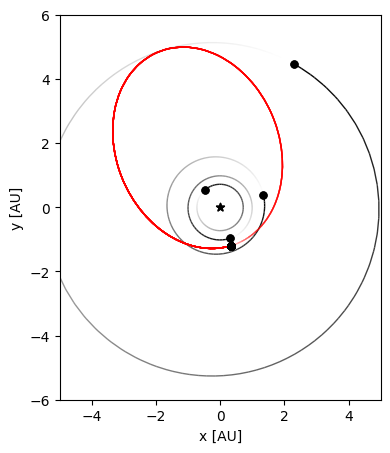

In [3]:
# Earliest snapshot in simulation

sim = sa[0]
rebound.OrbitPlot(sim, unitlabel = "[AU]", xlim = [-5, 5], ylim = [-6, 6],
                  color = (N_pl - 1) * ["black"] + N_tp * ["red"])

---------------------------------
REBOUND version:     	4.4.2
REBOUND built on:    	Jul 15 2024 18:47:33
Number of particles: 	9
Selected integrator: 	mercurius
Simulation time:     	9.1940000046221409e+06
Current timestep:    	0.024608
---------------------------------
<rebound.particle.Particle object at 0x254a61fded0, m=0.9999999999950272 x=0.004855807686783313 y=0.0004183092724011272 z=-9.656208491604247e-05 vx=-0.0010808483727913743 vy=0.002508126434973679 vz=1.3679103798233664e-05>
<rebound.particle.Particle object at 0x254a61ff450, m=2.447838287784771e-06 x=-0.487884343534067 y=-0.5428257312387478 z=0.009654707864980476 vx=5.192464428189059 vy=-5.102388566576229 vz=-0.1843002652606489>
<rebound.particle.Particle object at 0x254a61fded0, m=3.0404326489511185e-06 x=-0.7431064457322916 y=-0.6474340293510514 z=0.04757264440840366 vx=4.000724282622523 vy=-4.91411067535351 vz=-0.18229117501894718>
<rebound.particle.Particle object at 0x254a61ff450, m=3.2271560828978514e-07 x=0.3819001

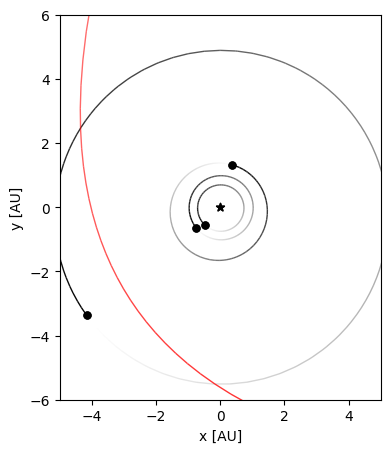

In [4]:
# Latest snapshot

sim = sa[-1]
rebound.OrbitPlot(sim, unitlabel = "[AU]", xlim = [-5, 5], ylim = [-6, 6],
                  color = (N_pl - 1) * ["black"] + N_tp * ["red"])
sim.status()

In [5]:
# Convert values into osculating orbital elements

orbits = sim.orbits()
for orbit in orbits:
    print(orbit)

<rebound.Orbit instance, a=0.723349459830615 e=0.04213465140697396 inc=0.029072584139036076 Omega=1.3089481087581556 omega=0.7172633713764656 f=1.949318561723416>
<rebound.Orbit instance, a=0.9999987440289988 e=0.03063657551709324 inc=0.05682091707985579 Omega=1.7239400410397085 omega=0.8399813706757362 f=1.2907431720355342>
<rebound.Orbit instance, a=1.523665777867575 e=0.09796647532993537 inc=0.095006431731805 Omega=0.5480809684248336 omega=0.6872535742458972 f=0.05926550069704195>
<rebound.Orbit instance, a=5.201754029505751 e=0.06059617323244308 inc=0.02569935858521763 Omega=1.6259066811172942 omega=0.04813525994730572 f=2.146613535520487>
<rebound.Orbit instance, a=9.550374475492124 e=0.018876169995638886 inc=0.04014867016569808 Omega=2.143677297267144 omega=1.6411771588123036 f=4.933359412176708>
<rebound.Orbit instance, a=19.192927484420643 e=0.011923451533576695 inc=0.019829007098868076 Omega=2.631112134700199 omega=3.3382241725638884 f=2.27973041908189>
<rebound.Orbit instance

EXTRACT INFORMATION ABOUT A SINGLE PARTICLE

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\rebound\simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


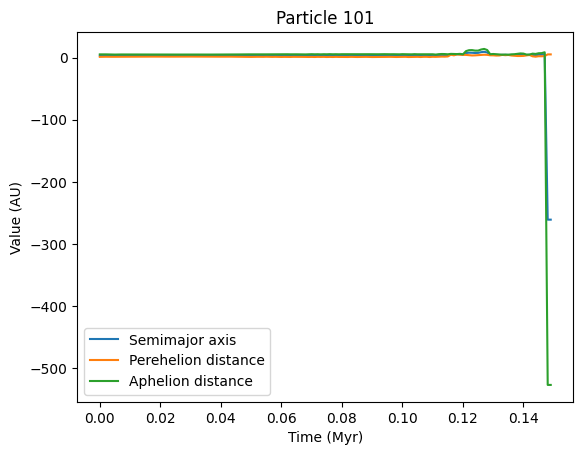

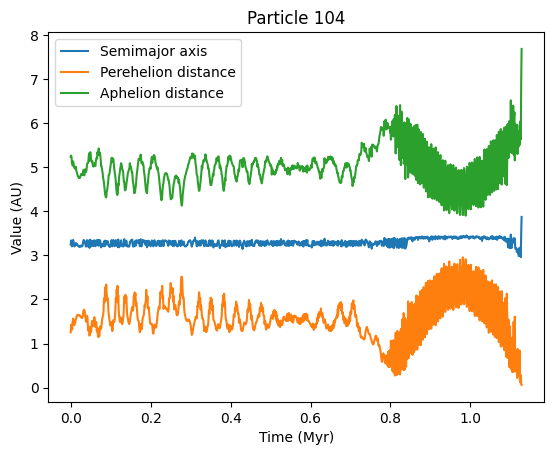

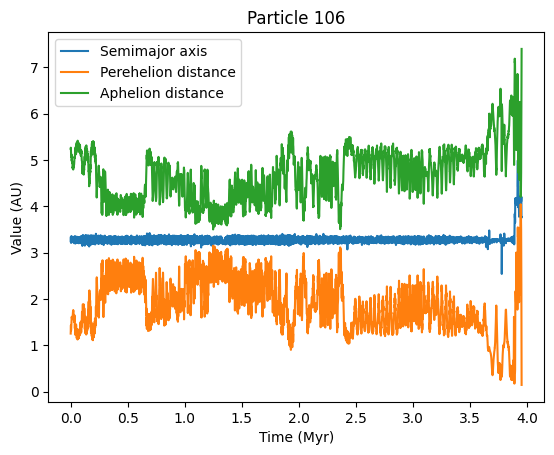

In [16]:
# a, q, Q plots for particles of interest

for pid in interest:

    t = np.zeros(len(sa))
    a = np.zeros(len(sa))
    e = np.zeros(len(sa))

    for i, sim in enumerate(sa):
        t[i] = sim.t / 1e6
        try:
            a[i] = sim.particles[h(pid)].a
            e[i] = sim.particles[h(pid)].e
        except rebound.ParticleNotFound: # Particle ejected
            a = a[:i]
            e = e[:i]
            t = t[:i]
            break

    # Add perehelion distance (q), aphelion distance (Q) to plot
    q = a * (1 - e)
    Q = a * (1 + e)

    plt.plot(t, a, label = "Semimajor axis")
    plt.plot(t, q, label = "Perehelion distance")
    plt.plot(t, Q, label = "Aphelion distance")
    plt.xlabel("Time (Myr)")
    plt.ylabel("Value (AU)")
    plt.title("Particle {0}".format(pid))
    plt.legend()
    plt.show()

MAKE A MOVIE OF PARTICLE'S ORBIT

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\rebound\simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


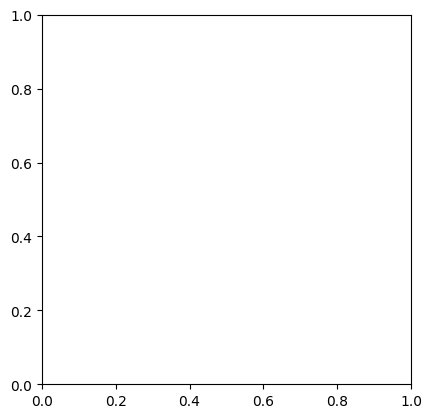

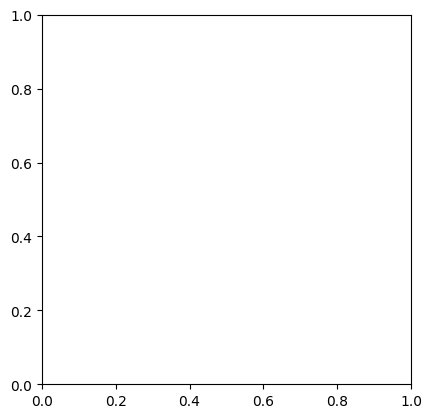

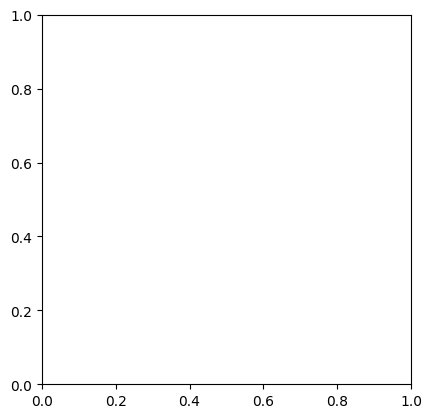

In [17]:
# Make movie of orbit's evolution from top-down perspective
# No idea why it's printing three blank frames

for pid in interest:

    count = 0 # Number frames consecutively
    fig, ax = plt.subplots()

    for i, sim in enumerate(sa):
        if i % 100: # Only plot every 100th frame
            continue

        try:
            op1 = rebound.OrbitPlot(sim, fig = fig, ax = ax, orbit_style = "solid",
                                    lw = 1, particles = [1, 2, 3, 4, 5, 6, 7])
            op1.particles.set_sizes([0])

            op2 = rebound.OrbitPlot(sa[0], fig = op1.fig, ax = op1.ax, 
                                    orbit_style = "solid", lw = 1, 
                                    particles = [h(pid)], color = "red")
            op2.particles.set_sizes([0])

            ax.set_aspect("equal")
            ax.set_xlim(-8, 8)
            ax.set_ylim(-8, 8)
            ax.set_xlabel("x [AU]")
            ax.set_ylabel("y [AU]")

            ax.set_title("Particle {0}".format(pid))
            ax.text(-4, -7, "t = {:4.1f} Myr".format(sim.t / 1e6))
            fig.savefig("outputs/orbital_integration/movie/{}/frame_{:04d}.png".format(pid, count))
            
            count += 1
            ax.clear()
        except rebound.ParticleNotFound:
            break
        


RESIDENCE PLOT SHOWING HOW THE SEMIMAJOR AXIS AND ECCENTRICITY OF CLONES CHANGE OVER TIME
(Started copy-pasting from PDF here so the code looks kind of bad)
(Don't bother using the code below here for now)

In [ ]:
# Semimajor axis and eccentricity of every clone at every time step
a_all = []
e_all = []

for i, sim in enumerate(sa):
    for pid in range(100,100+N_tp):
        try:
            a_all.append(sim.particles[h(pid)].a)
            e_all.append(sim.particles[h(pid)].e)
        except rebound.ParticleNotFound:
            continue # Continue on with the next clone


amin, amax = 0, 12
emin, emax = 0, 1
h2d,xedge,yedge,im = plt.hist2d(a_all, e_all, range=[[amin,amax],[emin,emax]], bins=(30, 30))
plt.xlabel("a (AU)")
plt.ylabel("e")

plt.colorbar()

# Initial position
a_init = 3.245761552052847
e_init = 0.6141866747698732
plt.plot(a_init,e_init,"*",color="r")

# plt.show()

# Loop over every snapshot and every test particle
sim = sa[-1]
a_tp = []
e_tp = []
for pid in range(100,100+N_tp):
    try:
        a_tp.append(sim.particles[h(pid)].a)
        e_tp.append(sim.particles[h(pid)].e)
    except:
        continue

plt.plot(a_tp,e_tp,"co")

# Add planets
a_pl = []
e_pl = []
for id in range(1,N_pl):
    a_pl.append(sim.particles[id].a)
    e_pl.append(sim.particles[id].e)
plt.plot(a_pl,e_pl,"yo")

In [ ]:
# Closer look, run it forward at a higher resolution
# The value of t doesn't work for some reason, idk why

sa = rebound.Simulationarchive("outputs/orbital_integration/archive.bin")
sim = sa[1063] # Use the index that is useful for you

archive = "outputs/orbital_integration/archive_new.bin"
tstart = sim.t # Start at the current time
tout = 1.0 # New output resolution
tend = 1000+tstart # End at the next timestep

sim.save_to_file(archive,interval=tout,delete_file=True)

sim.collision_resolve = "halt"

times = np.arange(tstart,tend,tout)
Nsteps = len(times)
for i in range(Nsteps):
    sim.integrate(times[i],exact_finish_time=0)
    print("Time {0:7.4f} Myr --Fraction Done {1:5.4f} -- # of clones {2}".format(
          sim.t/1e6,(sim.t-tstart)/(tend-tstart),sim.N-N_pl))

In [ ]:
# Plot distance between clone of interest and a planet (here, Jupiter/Saturn)

sa_new = rebound.Simulationarchive("outputs/orbital_integration/archive_new.bin")
pid = 110
d_Jupiter = np.zeros(len(sa_new))
d_Saturn = np.zeros(len(sa_new))
for i, sim in enumerate(sa_new):
    d_Jupiter[i] = ((sim.particles[h(pid)].x-sim.particles[h(4)].x)**2+
                    (sim.particles[h(pid)].y-sim.particles[h(4)].y)**2+
                    (sim.particles[h(pid)].z-sim.particles[h(4)].z)**2)**0.5
    d_Saturn[i] = ((sim.particles[h(pid)].x-sim.particles[h(5)].x)**2+
                   (sim.particles[h(pid)].y-sim.particles[h(5)].y)**2+
                   (sim.particles[h(pid)].z-sim.particles[h(5)].z)**2)**0.5
    
plt.plot(t,d_Jupiter,label="Jupiter")
plt.plot(t,d_Saturn,label="Saturn")
plt.xlabel("t (Myr)")
plt.ylabel("Distance to Planet (AU)")
plt.legend()